AI Assistance: OpenAI ChatGPT and Anthropic's Claude were used for code debugging, code generation, code organization, and code methodological brainstorming\. All final modeling, implementation, validation, commentary, and interpretation were performed and verified by the authors\.

# Bootstrap RMSE comparison across models

Compares test RMSE across several regression models using block bootstrap resampling
for confidence intervals, plotted as a bar chart with error bars.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import mean_squared_error

In [27]:
platform = 'deepnote'

if platform == 'deepnote':
    PROCESSED_DIR = Path('data/Processed')
if platform == 'vscode':
    PROCESSED_DIR = Path('work/Processed')

# I. Function definitions

## 1. `bootstrap_rmse`

In [28]:
def bootstrap_rmse(y_true, y_pred, n_bootstrap=1000, ci=95, random_state=42, block_length=1):
    """
    Estimate RMSE and a bootstrap confidence interval by resampling
    (y_true, y_pred) pairs with replacement.

    Parameters
    ----------
    y_true : array-like, shape (n,)
    y_pred : array-like, shape (n,)
    n_bootstrap : int, default 1000
    ci : float, default 95
        Confidence interval width as a percentage (95 -> 2.5/97.5 percentiles).
    random_state : int, default 42
    block_length : int, default 1
        Length of contiguous blocks resampled together (a moving block bootstrap).
        block_length=1 is the classic i.i.d. row-wise bootstrap, which assumes each row's error
        is independent of its neighbors - appropriate for i.i.d. data, but not for time-ordered
        data with autocorrelated errors (e.g. Kp geomagnetic activity, which persists over many
        consecutive 3-hour intervals). For that case, use a block_length long enough to exceed
        the residual autocorrelation range (see compute_acf/plot_acf below) so each resampled
        dataset preserves local temporal dependence instead of shattering it. Assumes y_true/
        y_pred are already in chronological order, as they are throughout this notebook.

    Returns
    -------
    result : dict
        {'rmse': point estimate on the full sample,
         'ci_lower': ..., 'ci_upper': ...,
         'boot_rmses': np.ndarray, shape (n_bootstrap,)}
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    rng = np.random.default_rng(random_state)

    # sqrt(MSE) rather than a `squared=False` kwarg, since that argument has
    # been removed from recent scikit-learn versions
    point_rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    boot_rmses = np.empty(n_bootstrap)
    for i in range(n_bootstrap):
        if block_length == 1:
            idx = rng.integers(0, n, size=n)
        else:
            # Moving block bootstrap: pick whole (overlapping) contiguous blocks of length
            # block_length rather than individual rows, so each resample preserves local
            # autocorrelation instead of shuffling it away.
            n_blocks = int(np.ceil(n / block_length))
            block_starts = rng.integers(0, n - block_length + 1, size=n_blocks)
            idx = np.concatenate(
                [np.arange(start, start + block_length) for start in block_starts]
            )[:n]
        boot_rmses[i] = np.sqrt(mean_squared_error(y_true[idx], y_pred[idx]))

    alpha = (100 - ci) / 2
    ci_lower, ci_upper = np.percentile(boot_rmses, [alpha, 100 - alpha])

    print(f'--- bootstrap_rmse: n={n}, n_bootstrap={n_bootstrap}, ci={ci}%, '
          f'block_length={block_length} ---')
    print(f'Point RMSE: {point_rmse:.4f}')
    print(f'{ci}% CI: [{ci_lower:.4f}, {ci_upper:.4f}]')

    return {'rmse': point_rmse, 'ci_lower': ci_lower, 'ci_upper': ci_upper, 'boot_rmses': boot_rmses}

## 2. `compute_bootstrap_results`

In [29]:
def compute_bootstrap_results(predictions, n_bootstrap=1000, ci=95, random_state=42, block_length=1):
    """
    Run bootstrap_rmse for each model in `predictions` and collect the
    results into a tidy DataFrame ready for plotting.

    Parameters
    ----------
    predictions : dict[str, tuple(array-like, array-like)]
        Maps model name -> (y_true, y_pred).
    n_bootstrap : int, default 1000
    ci : float, default 95
    random_state : int, default 42
        Reused for every model. When models share the same test set (same n,
        same row order), this makes every model draw the *same* resampled
        indices each iteration - a paired bootstrap, which is more sensitive
        for comparing models than resampling each independently.
    block_length : int, default 1
        Forwarded to bootstrap_rmse - see its docstring. 1 = i.i.d. bootstrap.

    Returns
    -------
    results_df : pd.DataFrame
        Columns: model, rmse, ci_lower, ci_upper, err_low, err_high
        (err_low/err_high are +/- offsets from rmse, ready for matplotlib's
        `yerr`.)
    """
    rows = []
    for model_name, (y_true, y_pred) in predictions.items():
        result = bootstrap_rmse(
            y_true, y_pred, n_bootstrap=n_bootstrap, ci=ci, random_state=random_state,
            block_length=block_length,
        )
        rows.append({
            'model': model_name,
            'rmse': result['rmse'],
            'ci_lower': result['ci_lower'],
            'ci_upper': result['ci_upper'],
            'err_low': result['rmse'] - result['ci_lower'],
            'err_high': result['ci_upper'] - result['rmse'],
        })

    results_df = pd.DataFrame(rows)
    print('--- compute_bootstrap_results: summary ---')
    print(results_df.to_string(index=False))
    return results_df

## 3. `plot_rmse_comparison`

Bar colors use the fixed categorical order from the project's validated
palette (`dataviz` skill, `references/palette.md`) rather than matplotlib's
default cycle - each model gets a distinct, CVD-safe hue in the same order
every time. Any bar named in `muted_models` (e.g. a naive/climatology
baseline) is rendered in chrome gray instead, since it's a reference point
rather than a candidate model competing on equal footing.

In [30]:
CATEGORICAL_COLORS = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100',
                       '#e87ba4', '#008300', '#4a3aa7', '#e34948']
MUTED_COLOR = '#c3c2b7'


def plot_rmse_comparison(results_df, muted_models=None, no_error_bar_models=None, reference_rmse=None,
                          reference_label=None, title='Test RMSE by model (bootstrap 95% CI)'):
    """
    Bar chart of RMSE per model with bootstrap CI error bars, optionally with
    a dashed horizontal reference line (e.g. a prior baseline's RMSE).

    Parameters
    ----------
    results_df : pd.DataFrame
        Output of compute_bootstrap_results (needs model, rmse, err_low, err_high).
    muted_models : list of str, optional
        Model names to render in muted gray instead of a categorical hue.
    no_error_bar_models : list of str, optional
        Model names to plot without error bars (e.g. a reference model whose CI isn't of interest).
    reference_rmse : float, optional
        If given, draws a horizontal dashed reference line.
    reference_label : str, optional
        Legend label for the reference line. Defaults to the RMSE value.
    title : str

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """
    muted_models = set(muted_models or [])
    no_error_bar_models = set(no_error_bar_models or [])

    colors = []
    hue_i = 0
    for model in results_df['model']:
        if model in muted_models:
            colors.append(MUTED_COLOR)
        else:
            colors.append(CATEGORICAL_COLORS[hue_i % len(CATEGORICAL_COLORS)])
            hue_i += 1

    fig, ax = plt.subplots(figsize=(7, 5))

    hide_err = results_df['model'].isin(no_error_bar_models)
    err_low = results_df['err_low'].mask(hide_err, np.nan)
    err_high = results_df['err_high'].mask(hide_err, np.nan)
    yerr = np.vstack([err_low, err_high])

    ax.bar(results_df['model'], results_df['rmse'], yerr=yerr, capsize=4,
           color=colors, edgecolor='#0b0b0b', linewidth=0.5,
           error_kw={'ecolor': '#52514e', 'elinewidth': 1.2})

    if reference_rmse is not None:
        ax.axhline(reference_rmse, linestyle='--', color='#52514e', linewidth=1.2,
                    label=reference_label or f'Reference ({reference_rmse:.4f})')
        ax.legend(frameon=False)

    ax.set_ylabel('RMSE')
    ax.set_title(title)
    ax.set_axisbelow(True)
    ax.grid(axis='y', color='#e1e0d9', linewidth=0.8)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
    for spine in ('left', 'bottom'):
        ax.spines[spine].set_color('#c3c2b7')
    ax.tick_params(colors='#52514e')
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()

    return fig, ax

## 4. `load_horizon_predictions`

Loads bootstrap prediction pairs for one model across multiple forecast horizons, from the
`bootstrap_predictions_{horizon}.csv` files exported by
`07a_linear_regression_train_val_test.ipynb`. Returns a dict shaped exactly like
`compute_bootstrap_results` expects - but keyed by horizon label instead of model name, so passing
the result straight through `compute_bootstrap_results` + `plot_rmse_comparison` produces a bar
chart comparing one model across horizons, reusing both functions unchanged.

In [31]:
def load_horizon_predictions(model_name, horizons, processed_dir=PROCESSED_DIR):
    """
    Load (y_true, y_pred) pairs for one model across multiple forecast horizons.

    Parameters
    ----------
    model_name : str
        e.g. 'OLS', 'Lasso', 'Persistence' - must match the `model` column values written by
        07d_linear_regression_train_val_test.ipynb's export_bootstrap_predictions.
    horizons : list of str
        e.g. ['0h', '3h', '6h'].
    processed_dir : Path

    Returns
    -------
    predictions : dict[str, tuple(np.ndarray, np.ndarray)]
        Maps horizon label -> (y_true, y_pred).
    """
    predictions = {}
    for horizon in horizons:
        path = processed_dir / f'bootstrap_predictions_{horizon}.csv'
        df = pd.read_csv(path)

        df_model = df[df['model'] == model_name]
        if df_model.empty:
            raise ValueError(f"No rows found for model='{model_name}' in {path}")

        predictions[horizon] = (df_model['y_true'].to_numpy(), df_model['y_pred'].to_numpy())
        print(f'Loaded {len(df_model):,} rows for model={model_name}, horizon={horizon} from {path}')

    return predictions

## 5. `compute_acf`

In [32]:
def compute_acf(x, max_lag=40):
    """
    Compute the sample autocorrelation function (ACF) of a 1D series up to max_lag, via the
    standard biased estimator (divide by n at every lag, not n-lag) - the usual convention for
    ACF plots.

    Parameters
    ----------
    x : array-like, shape (n,)
    max_lag : int, default 40

    Returns
    -------
    acf : np.ndarray, shape (max_lag + 1,)
        acf[0] is always 1.0 by construction.
    """
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    n = len(x)
    denom = np.dot(x, x) / n
    acf = np.array([np.dot(x[:n - lag], x[lag:]) / n / denom for lag in range(max_lag + 1)])
    return acf

## 6. `plot_acf`

In [33]:
def plot_acf(acf_values, n, title='Residual autocorrelation'):
    """
    Bar plot of an autocorrelation function with a rough +/-1.96/sqrt(n) band - the usual
    approximate 95% band for "is this lag distinguishable from zero autocorrelation" under a
    white-noise null.

    Parameters
    ----------
    acf_values : np.ndarray
        Output of compute_acf.
    n : int
        Series length used to compute acf_values - determines the significance band width.
    title : str

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """
    lags = np.arange(len(acf_values))
    band = 1.96 / np.sqrt(n)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(lags, acf_values, width=0.6, color=CATEGORICAL_COLORS[0], edgecolor='#0b0b0b', linewidth=0.5)
    ax.axhline(band, linestyle='--', color='#52514e', linewidth=1)
    ax.axhline(-band, linestyle='--', color='#52514e', linewidth=1)
    ax.axhline(0, color='#0b0b0b', linewidth=0.8)
    ax.set_xlabel('Lag (x 3-hour intervals)')
    ax.set_ylabel('Autocorrelation')
    ax.set_title(title)
    ax.set_axisbelow(True)
    ax.grid(axis='y', color='#e1e0d9', linewidth=0.8)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
    for spine in ('left', 'bottom'):
        ax.spines[spine].set_color('#c3c2b7')
    ax.tick_params(colors='#52514e')
    plt.tight_layout()
    plt.show()

    return fig, ax

## 7. `plot_ci_width_comparison`

In [34]:
def plot_ci_width_comparison(comparison_df, title='Bootstrap CI width: i.i.d. vs block'):
    """
    Grouped bar chart comparing i.i.d.-bootstrap CI width against block-bootstrap CI width for
    each model/horizon label - visualizes how much an autocorrelation-aware resample widens the
    uncertainty estimate versus the naive row-wise bootstrap. i.i.d. is rendered in the same
    muted gray plot_rmse_comparison uses for reference/baseline bars, since it's the prior
    (naive) method here, not a competing candidate.

    Parameters
    ----------
    comparison_df : pd.DataFrame
        Needs columns: model, width_iid, width_block.
    title : str

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """
    x = np.arange(len(comparison_df))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width / 2, comparison_df['width_iid'], width, label='i.i.d. bootstrap',
           color=MUTED_COLOR, edgecolor='#0b0b0b', linewidth=0.5)
    ax.bar(x + width / 2, comparison_df['width_block'], width, label='Block bootstrap',
           color=CATEGORICAL_COLORS[0], edgecolor='#0b0b0b', linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(comparison_df['model'], rotation=15, ha='right')
    ax.set_ylabel('95% CI width (RMSE)')
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.set_axisbelow(True)
    ax.grid(axis='y', color='#e1e0d9', linewidth=0.8)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
    for spine in ('left', 'bottom'):
        ax.spines[spine].set_color('#c3c2b7')
    ax.tick_params(colors='#52514e')
    plt.tight_layout()
    plt.show()

    return fig, ax

# II. Single model across forecast horizons

Uses `load_horizon_predictions` to compare one model's test-set RMSE across the three forecast
horizons (0h/3h/6h), reading the real `bootstrap_predictions_{horizon}.csv` files from the most
recent `07a_linear_regression_train_val_test.ipynb` run. Run below for the Lasso model, with the persistence baseline plotted alongside the 3h/6h bars (muted gray).

In [43]:
HORIZONS = ['0h', '3h', '6h']
PERSISTENCE_HORIZONS = ['3h', '6h']  # 0h persistence omitted - see markdown note above
MODEL_NAME = 'Lasso'
REFERENCE_MODEL_NAME = 'Persistence'

lasso_horizon_predictions = load_horizon_predictions(MODEL_NAME, HORIZONS, PROCESSED_DIR)
persistence_horizon_predictions = load_horizon_predictions(REFERENCE_MODEL_NAME, PERSISTENCE_HORIZONS, PROCESSED_DIR)

combined_predictions = {}
for horizon in HORIZONS:
    combined_predictions[f'{horizon} {MODEL_NAME}'] = lasso_horizon_predictions[horizon]
    if horizon in PERSISTENCE_HORIZONS:
        combined_predictions[f'{horizon} {REFERENCE_MODEL_NAME}'] = persistence_horizon_predictions[horizon]

Loaded 8,158 rows for model=Lasso, horizon=0h from work\Processed\bootstrap_predictions_0h.csv
Loaded 8,157 rows for model=Lasso, horizon=3h from work\Processed\bootstrap_predictions_3h.csv
Loaded 8,156 rows for model=Lasso, horizon=6h from work\Processed\bootstrap_predictions_6h.csv
Loaded 8,157 rows for model=Persistence, horizon=3h from work\Processed\bootstrap_predictions_3h.csv
Loaded 8,156 rows for model=Persistence, horizon=6h from work\Processed\bootstrap_predictions_6h.csv


## Choosing a block length

Autocorrelation of the 3h-horizon Lasso residuals (y_true - y_pred), up to a 5-day lag (40 x
3-hour intervals). The dashed band is the approximate 95% white-noise significance threshold
(+/-1.96/sqrt(n)) - lags outside it are distinguishable from zero autocorrelation.

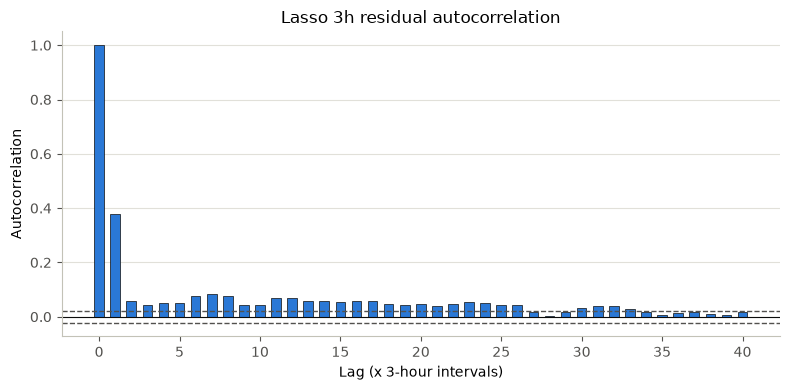

In [44]:
lasso_3h_y_true, lasso_3h_y_pred = combined_predictions['3h Lasso']
lasso_3h_residuals = lasso_3h_y_true - lasso_3h_y_pred

acf_values = compute_acf(lasso_3h_residuals, max_lag=40)
fig, ax = plot_acf(acf_values, n=len(lasso_3h_residuals), title='Lasso 3h residual autocorrelation')

In [45]:
n_resid = len(lasso_3h_residuals)
band = 1.96 / np.sqrt(n_resid)

# Skip lag 0 (always 1.0 by construction) when looking for where ACF drops into the band
below_band = np.abs(acf_values[1:]) < band
first_below = int(np.argmax(below_band)) + 1 if below_band.any() else len(acf_values)
print(f'First lag with |ACF| below the ~95% white-noise band: {first_below} (~{first_below * 3}h)')

# Safety margin: double the empirical decorrelation lag, floored at 8 (~1 day of 3-hour records) -
# Kp storms commonly run 1-3+ days, so a block shorter than that would still cut across a single
# storm's autocorrelated error run.
BLOCK_LENGTH = max(first_below * 2, 8)
print(f'Using block_length = {BLOCK_LENGTH} ({BLOCK_LENGTH * 3}h) for the block bootstrap below')

First lag with |ACF| below the ~95% white-noise band: 27 (~81h)
Using block_length = 54 (162h) for the block bootstrap below


In [46]:
# Score with the block bootstrap given the autocorrelation found above
lasso_horizon_results = compute_bootstrap_results(
    combined_predictions, n_bootstrap=1000, ci=95, random_state=42, block_length=BLOCK_LENGTH,
)

--- bootstrap_rmse: n=8158, n_bootstrap=1000, ci=95%, block_length=54 ---
Point RMSE: 0.7559
95% CI: [0.7281, 0.7891]
--- bootstrap_rmse: n=8157, n_bootstrap=1000, ci=95%, block_length=54 ---
Point RMSE: 0.9567
95% CI: [0.9200, 0.9905]
--- bootstrap_rmse: n=8157, n_bootstrap=1000, ci=95%, block_length=54 ---
Point RMSE: 0.9075
95% CI: [0.8803, 0.9319]
--- bootstrap_rmse: n=8156, n_bootstrap=1000, ci=95%, block_length=54 ---
Point RMSE: 1.0566
95% CI: [1.0101, 1.0981]
--- bootstrap_rmse: n=8156, n_bootstrap=1000, ci=95%, block_length=54 ---
Point RMSE: 1.1645
95% CI: [1.1216, 1.2021]
--- compute_bootstrap_results: summary ---
         model     rmse  ci_lower  ci_upper  err_low  err_high
      0h Lasso 0.755945  0.728095  0.789054 0.027850  0.033108
      3h Lasso 0.956665  0.919976  0.990497 0.036689  0.033832
3h Persistence 0.907460  0.880341  0.931940 0.027119  0.024480
      6h Lasso 1.056583  1.010112  1.098145 0.046471  0.041562
6h Persistence 1.164518  1.121586  1.202101 0.042932

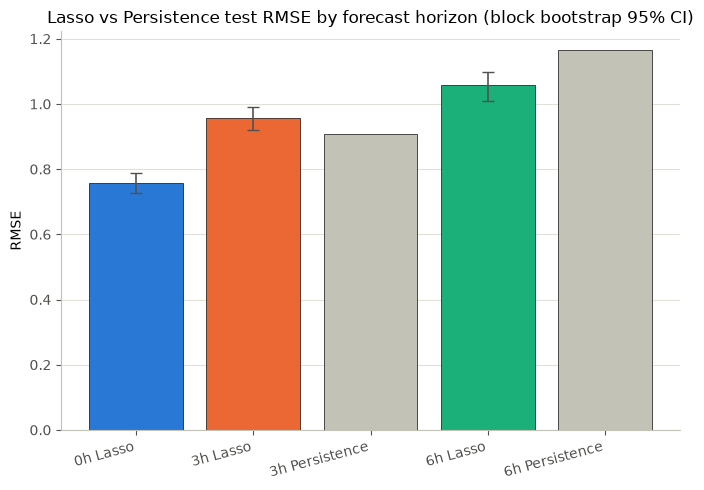

In [47]:
persistence_labels = [f'{horizon} {REFERENCE_MODEL_NAME}' for horizon in PERSISTENCE_HORIZONS]

fig, ax = plot_rmse_comparison(
    lasso_horizon_results,
    muted_models=persistence_labels,
    no_error_bar_models=persistence_labels,
    title=f'{MODEL_NAME} vs {REFERENCE_MODEL_NAME} test RMSE by forecast horizon (block bootstrap 95% CI)',
)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=4a18bf7d-431c-4909-af8a-a54a62228a78' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>